- japonica: NH001 NH002 NH003 NH005
- indica: NH006 NH007 NH008 NH009
- genome: /mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.asm.ch.fa
- annotation: /mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.all_models.gff3
- leaf_ck: /mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck
- leaf_salt: /mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt


1. **峰值位点（Lead SNP）**：位于 **5号染色体（Chr. 5）的 28,351,660 bp** 处，该位点被命名为 **qSTS5**（Salt Tolerance Site 5）。

2. **初步候选区间（用于初筛）**：研究优先关注了该峰值位点 **上游和下游各 200 kb** 的区域（即 Chr5: 28,151,660 ~ 28,551,660），在此范围内初步筛选出了 **97个** 候选基因。

3. **核心精细定位区间（用于多组学交集）**：在进一步的整合分析（结合DEGs、eQTL和GWAS）中，这97个候选基因被定位在峰值附近一个更精确的基因组区域内，原文描述为 **“S46.49 Kb”**（从上下文推测“S”应为“~”约等于，即 **约 46.49 kb** 的区间）。随后，通过基于非同义突变的单倍型分析，将候选基因进一步缩小至 **31个**。

**总结**：GWAS信号的最显著峰值在 **5号染色体 28,351,660 bp**，研究主要围绕该位点 **±200 kb** 的区间进行候选基因挖掘，最终通过多组学数据将核心区间聚焦在峰值附近 **约46.49 kb** 的范围内。

In [3]:
!ls /mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links

leaf_ck  leaf_low_n  leaf_salt	panicle  root_ck  root_salt


In [4]:
import gzip
import os

# 参数设置
gff_path = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.all_models.gff3"
fasta_path = "/mnt/rice/default/Workspace/yangdong/ai4research/rice_server/source/rice_mut/osa1_r7.asm.ch.fa"

target_chroms = {"Chr5", "chr5", "chr05", "5"}
region_start = 28151660
region_end = 28551660

def parse_gff_attributes(attr_str):
    """解析 GFF3 的 Ninth column (Attributes)"""
    attrs = {}
    for item in attr_str.strip().split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            attrs[k] = v
    return attrs

def get_genes_in_region(gff_file, target_chroms, start, end):
    genes = []
    open_fn = gzip.open if gff_file.endswith(".gz") else open
    
    with open_fn(gff_file, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
            
            chrom, source, feature_type, g_start, g_end, score, strand, phase, attr = parts
            
            # 判断染色体及类型 (gene 或 mRNA)
            if chrom in target_chroms and feature_type in ["gene"]:
                g_start = int(g_start)
                g_end = int(g_end)
                
                # 判断区间重叠 (Start1 <= End2 AND End1 >= Start2)
                if g_start <= end and g_end >= start:
                    attrs = parse_gff_attributes(attr)
                    gene_id = attrs.get("ID", attrs.get("Name", "Unknown"))
                    genes.append({
                        "id": gene_id,
                        "chrom": chrom,
                        "start": g_start,
                        "end": g_end,
                        "strand": strand,
                        "feature_type": feature_type,
                        "attributes": attrs
                    })
    return genes

def extract_fasta_sequence(fasta_file, chroms, start, end):
    """读取指定区域的基因组序列"""
    seq_chunks = []
    current_chrom = None
    open_fn = gzip.open if fasta_file.endswith(".gz") else open
    
    with open_fn(fasta_file, "rt") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                current_chrom = line[1:].split()[0]
            elif current_chrom in chroms:
                seq_chunks.append(line)
                
    full_seq = "".join(seq_chunks)
    # 提取切片 (1-based coordinate 转换为 0-based python slice)
    region_seq = full_seq[start - 1 : end]
    return region_seq

# 1. 获取基因列表
genes = get_genes_in_region(gff_path, target_chroms, region_start, region_end)

print(f"在 Chr5:{region_start:,}~{region_end:,} 区域共找到 {len(genes)} 个基因/转录本功能特征：\n")
print(f"{'ID':<25} {'Type':<8} {'Start':<12} {'End':<12} {'Strand':<6}")
print("-" * 65)

for g in genes:
    print(f"{g['id']:<25} {g['feature_type']:<8} {g['start']:<12} {g['end']:<12} {g['strand']:<6}")

# 2. (可选) 提取该区域的基因组 FASTA 序列
region_dna = extract_fasta_sequence(fasta_path, target_chroms, region_start, region_end)
print(f"\n区域序列长度: {len(region_dna)} bp")

在 Chr5:28,151,660~28,551,660 区域共找到 69 个基因/转录本功能特征：

ID                        Type     Start        End          Strand
-----------------------------------------------------------------
LOC_Os05g49100            gene     28154693     28157989     +     
LOC_Os05g49110            gene     28164754     28168896     -     
LOC_Os05g49120            gene     28176577     28182471     +     
LOC_Os05g49130            gene     28183127     28188697     +     
LOC_Os05g49140            gene     28188762     28194025     -     
LOC_Os05g49150            gene     28202084     28204227     -     
LOC_Os05g49160            gene     28205457     28208652     -     
LOC_Os05g49164            gene     28210407     28212525     +     
LOC_Os05g49170            gene     28213808     28216045     -     
LOC_Os05g49180            gene     28220108     28228800     +     
LOC_Os05g49200            gene     28231688     28237488     +     
LOC_Os05g49210            gene     28238562     28241041     +    

In [5]:
genes[:5]

[{'id': 'LOC_Os05g49100',
  'chrom': 'Chr5',
  'start': 28154693,
  'end': 28157989,
  'strand': '+',
  'feature_type': 'gene',
  'attributes': {'ID': 'LOC_Os05g49100',
   'Name': 'LOC_Os05g49100',
   'Note': 'WRKY49%2C%20expressed'}},
 {'id': 'LOC_Os05g49110',
  'chrom': 'Chr5',
  'start': 28164754,
  'end': 28168896,
  'strand': '-',
  'feature_type': 'gene',
  'attributes': {'ID': 'LOC_Os05g49110',
   'Name': 'LOC_Os05g49110',
   'Note': 'retrotransposon%20protein%2C%20putative%2C%20Ty1-copia%20subclass%2C%20expressed'}},
 {'id': 'LOC_Os05g49120',
  'chrom': 'Chr5',
  'start': 28176577,
  'end': 28182471,
  'strand': '+',
  'feature_type': 'gene',
  'attributes': {'ID': 'LOC_Os05g49120',
   'Name': 'LOC_Os05g49120',
   'Note': 'NLI%20interacting%20factor-like%20phosphatase%2C%20putative%2C%20expressed'}},
 {'id': 'LOC_Os05g49130',
  'chrom': 'Chr5',
  'start': 28183127,
  'end': 28188697,
  'strand': '+',
  'feature_type': 'gene',
  'attributes': {'ID': 'LOC_Os05g49130',
   'Name': 

In [6]:
import pandas as pd

# 假设 genes 是通过上一版代码获取到的字典列表
# genes = get_genes_in_region(gff_path, target_chroms, region_start, region_end)

# 转换为 DataFrame
df = pd.DataFrame(genes)

# 可选：如果包含 attributes 字典列，提取或去除复杂属性列以保持表格整洁
if "attributes" in df.columns:
    # 例如提取 Description/Name 属性，然后删掉原始 attributes 字典
    df["Name"] = df["attributes"].apply(lambda x: x.get("Name", x.get("ID", "")))
    df["Description"] = df["attributes"].apply(lambda x: x.get("description", x.get("Note", "")))
    df = df.drop(columns=["attributes"])

# 保存为 CSV 文件
output_csv = "Chr5_28151660_28551660_genes.csv"
df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"已成功导出 {len(df)} 条记录到 CSV 文件: {output_csv}")

已成功导出 69 条记录到 CSV 文件: Chr5_28151660_28551660_genes.csv


In [7]:
df.head()

,id,chrom,start,end,strand,feature_type,Name,Description
0,LOC_Os05g49100,Chr5,28154693,28157989,+,gene,LOC_Os05g49100,WRKY49%2C%20expressed
1,LOC_Os05g49110,Chr5,28164754,28168896,-,gene,LOC_Os05g49110,retrotransposon%20protein%2C%20putative%2C%20T...
2,LOC_Os05g49120,Chr5,28176577,28182471,+,gene,LOC_Os05g49120,NLI%20interacting%20factor-like%20phosphatase%...
3,LOC_Os05g49130,Chr5,28183127,28188697,+,gene,LOC_Os05g49130,16S%20rRNA%20processing%20protein%20RimM%20con...
4,LOC_Os05g49140,Chr5,28188762,28194025,-,gene,LOC_Os05g49140,CGMC_MAPKCMGC_2.8%20-%20CGMC%20includes%20CDA%...


In [8]:
import os
import re

# 1. 样本列表定义
japonica = ["NH001", "NH002", "NH003", "NH005"]
indica = ["NH006", "NH007", "NH008", "NH009"]
all_samples = japonica + indica

# 2. 目录路径定义
dirs = {
    "leaf_ck": "/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck",
    "leaf_salt": "/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt"
}

# 3. 初始化结果字典
sample_files = {sample: [] for sample in all_samples}

# 4. 遍历目录并匹配绝对路径
for condition, dir_path in dirs.items():
    if not os.path.exists(dir_path):
        print(f"警告: 路径不存在 -> {dir_path}")
        continue
        
    for root, _, files in os.walk(dir_path):
        for file in files:
            # 仅匹配 .bw 或 .bigwig 文件（可根据实际后缀调整）
            if file.endswith((".bw", ".bigwig")):
                full_path = os.path.abspath(os.path.join(root, file))
                
                # 遍历样本名称进行正则匹配
                for sample in all_samples:
                    # 正则表达: 匹配以样本名开头，后接非字母数字字符（如 _ 或 -）的模式
                    pattern = rf"^{sample}(?=[^a-zA-Z0-9]|$)"
                    if re.search(pattern, file):
                        sample_files[sample].append(full_path)

# 打印最终构建的字典
import pprint
pprint.pprint(sample_files)

{'NH001': ['/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH001__Heibiao__SRR13451351.tmm_cpm_log2_plus1_coverage.bw',
           '/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt/NH001__Heibiao__SRR25894121.tmm_cpm_log2_plus1_coverage.bw'],
 'NH002': ['/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH002__Sansuijin__SRR13451349.tmm_cpm_log2_plus1_coverage.bw',
           '/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt/NH002__Sansuijin__SRR25894120.tmm_cpm_log2_plus1_coverage.bw'],
 'NH003': ['/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH003__Zaoshengbai__SRR13451348.tmm_cpm_log2_plus1_coverage.bw',
           '/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_

In [9]:
sample_files

{'NH001': ['/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH001__Heibiao__SRR13451351.tmm_cpm_log2_plus1_coverage.bw',
  '/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt/NH001__Heibiao__SRR25894121.tmm_cpm_log2_plus1_coverage.bw'],
 'NH002': ['/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH002__Sansuijin__SRR13451349.tmm_cpm_log2_plus1_coverage.bw',
  '/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt/NH002__Sansuijin__SRR25894120.tmm_cpm_log2_plus1_coverage.bw'],
 'NH003': ['/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH003__Zaoshengbai__SRR13451348.tmm_cpm_log2_plus1_coverage.bw',
  '/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/le

In [22]:
import pyBigWig
test_bw = sample_files['NH002'][0]
bw = pyBigWig.open(test_bw)

print("BigWig 中的染色体及长度:", bw.chroms())
bw.close()

BigWig 中的染色体及长度: {'GWHDRAN00000001': 43767753, 'GWHDRAN00000002': 24039641, 'GWHDRAN00000003': 29426682, 'GWHDRAN00000004': 27529058, 'GWHDRAN00000005': 36451886, 'GWHDRAN00000006': 37792972, 'GWHDRAN00000007': 35394677, 'GWHDRAN00000008': 30104249, 'GWHDRAN00000009': 31694700, 'GWHDRAN00000010': 29904543, 'GWHDRAN00000011': 28525469, 'GWHDRAN00000012': 23126841}


In [23]:
import pyBigWig

# 拿字典里的第一个文件测试
test_bw = sample_files['NH001'][0]
bw = pyBigWig.open(test_bw)

print("BigWig 中的染色体及长度:", bw.chroms())
bw.close()

BigWig 中的染色体及长度: {'GWHDRAM00000001': 43500536, 'GWHDRAM00000002': 25342113, 'GWHDRAM00000003': 29250786, 'GWHDRAM00000004': 26730703, 'GWHDRAM00000005': 36082031, 'GWHDRAM00000006': 37695486, 'GWHDRAM00000007': 32875394, 'GWHDRAM00000008': 29996347, 'GWHDRAM00000009': 31415545, 'GWHDRAM00000010': 30304653, 'GWHDRAM00000011': 28705863, 'GWHDRAM00000012': 22560978}


/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH001__Heibiao__SRR13451351.tmm_cpm_log2_plus1_coverage.bw GWHDRAM00000005
/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_salt/NH001__Heibiao__SRR25894121.tmm_cpm_log2_plus1_coverage.bw GWHDRAM00000005
/mnt/rice/default/Workspace/xuxiaolong/RNAprediction/RNA_bam/analysis/six_context_tmm_bigwig_links/leaf_ck/NH002__Sansuijin__SRR13451349.tmm_cpm_log2_plus1_coverage.bw GWHDRAM00000005


RuntimeError: Invalid interval bounds!

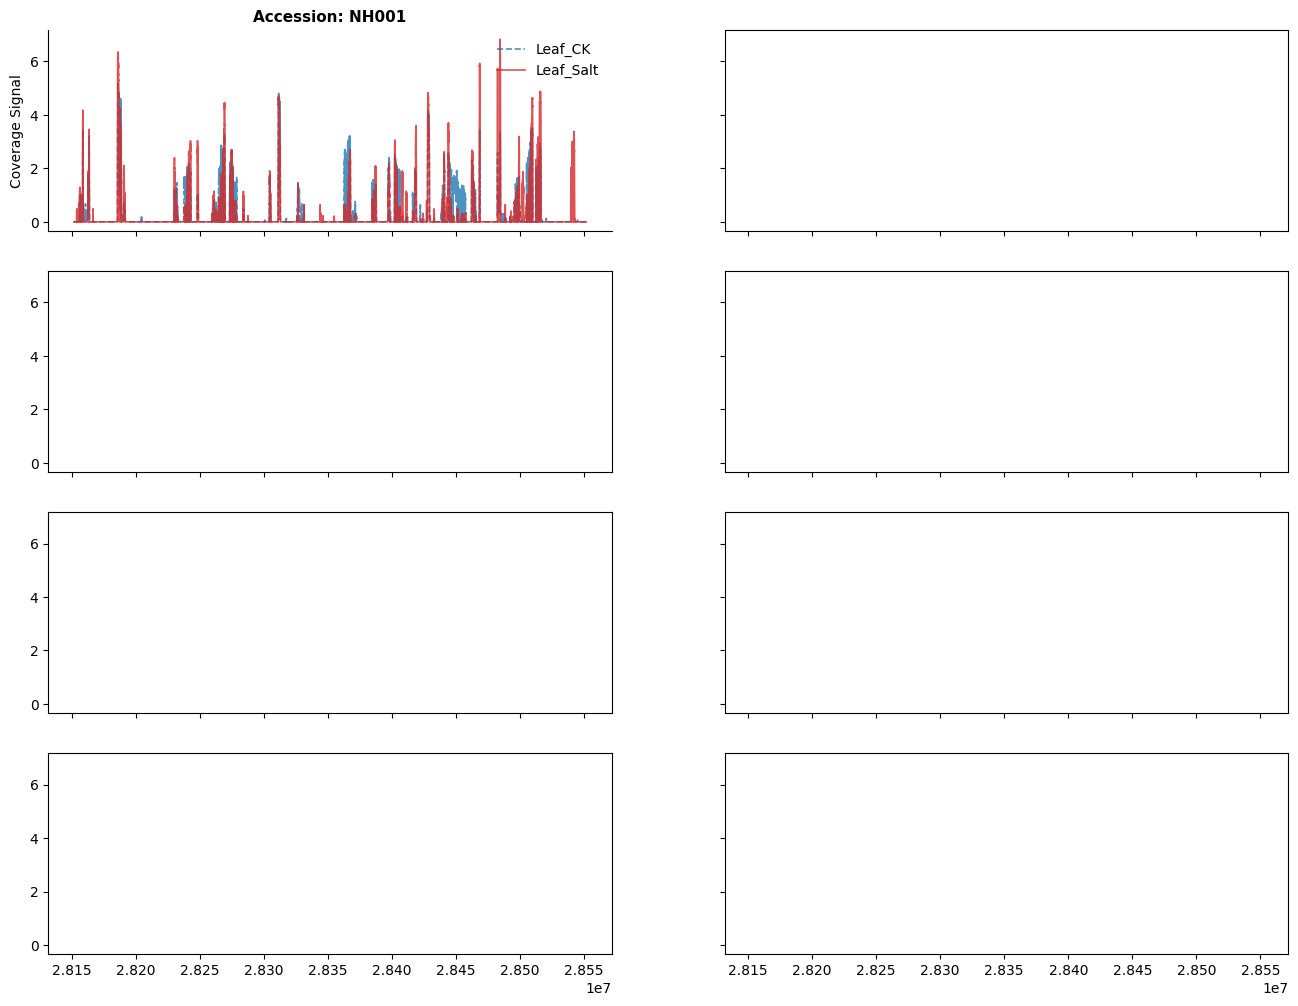

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyBigWig
from scipy.stats import mannwhitneyu


# 目标基因 LOC_Os05g49700 区域信息 (1-based转换为0-based Python坐标)
chrom = "Chr5"  # 如提示 KeyError，可改为 'chr5' 或 'chr05'
start = 28151660
end = 28551660

CHROM_MAP = {
    'Chr1': 'GWHDRAM00000001',
    'Chr2': 'GWHDRAM00000002',
    'Chr3': 'GWHDRAM00000003',
    'Chr4': 'GWHDRAM00000004',
    'Chr5': 'GWHDRAM00000005',
    'Chr6': 'GWHDRAM00000006',
    'Chr7': 'GWHDRAM00000007',
    'Chr8': 'GWHDRAM00000008',
    'Chr9': 'GWHDRAM00000009',
    'Chr10': 'GWHDRAM00000010',
    'Chr11': 'GWHDRAM00000011',
    'Chr12': 'GWHDRAM00000012',
}

def read_bw_values(bw_file, chrom, start, end):
    bw = pyBigWig.open(bw_file)
    chroms = bw.chroms()
    # print(chroms)
    # # 自动适配染色体前缀匹配
    # if chrom not in chroms:
    #     if f"chr{chrom.replace('Chr', '')}" in chroms:
    #         chrom = f"chr{chrom.replace('Chr', '')}"
    #     elif chrom.replace("Chr", "") in chroms:
    #         chrom = chrom.replace("Chr", "")
    # # 2. 正则表达式提取数字匹配 (如从 Chr5 中提取 5 后在 chroms 寻找末尾为 5 的键)
    # if not chrom:
    #     num_match = re.search(r'\d+', str(chrom))
    #     if num_match:
    #         c_num = int(num_match.group())
    #         for k in chroms.keys():
    #             if k.endswith(f"{c_num:08d}") or k.endswith(f"{c_num:02d}"):
    #                 chrom = k
    #                 break

    # 3. 如果前两者都匹配不上，使用固定对应关系匹配
    if chrom not in chroms:
        chrom = CHROM_MAP.get(str(chrom))

    print(bw_file, chrom)  
    vals = bw.values(chrom, start, end)
    bw.close()
    return np.nan_to_num(np.array(vals))

# 2. 提取数据
x_coords = np.arange(start, end)
express_data = []  # 存储聚合均值表达量用于画柱状图

fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (sample, (ck_path, salt_path)) in enumerate(sample_files.items()):
    ax = axes[i]
    
    # 提取 CK 与 Salt 覆盖度值
    ck_signal = read_bw_values(ck_path, chrom, start, end)
    salt_signal = read_bw_values(salt_path, chrom, start, end)
    
    # 汇总均值表达量 (或用 np.sum 汇总)
    express_data.append({"Sample": sample, "Group": "Leaf_CK", "Expression": np.mean(ck_signal)})
    express_data.append({"Sample": sample, "Group": "Leaf_Salt", "Expression": np.mean(salt_signal)})
    
    # 绘制 Track 图：CK 为虚线，Salt 为实线
    ax.plot(x_coords, ck_signal, label="Leaf_CK", linestyle="--", color="#1f77b4", alpha=0.8, linewidth=1.2)
    ax.plot(x_coords, salt_signal, label="Leaf_Salt", linestyle="-", color="#d62728", alpha=0.8, linewidth=1.2)
    
    ax.set_title(f"Accession: {sample}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Coverage Signal")
    ax.legend(loc="upper right", frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.xlabel(f"{chrom} Position (bp)")
plt.suptitle(f"Track View of LOC_Os05g49700 ({chrom}:{start:,}-{end:,})", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("LOC_Os05g49700_tracks.png", dpi=300)
plt.show()

# 3. 绘制带有误差棒与 Mann-Whitney U 检验显著性标注的表达量柱状图
df_exp = pd.DataFrame(express_data)

# 进行 Mann-Whitney U 检验 (即 U 检验)
ck_vals = df_exp[df_exp["Group"] == "Leaf_CK"]["Expression"]
salt_vals = df_exp[df_exp["Group"] == "Leaf_Salt"]["Expression"]
stat, p_val = mannwhitneyu(ck_vals, salt_vals, alternative='two-sided')

# 显著性星号判定
if p_val < 0.001:
    sig_symbol = "***"
elif p_val < 0.01:
    sig_symbol = "**"
elif p_val < 0.05:
    sig_symbol = "*"
else:
    sig_symbol = "ns"

plt.figure(figsize=(6, 7))
palette = {"Leaf_CK": "#1f77b4", "Leaf_Salt": "#d62728"}

# 柱状图 + 误差棒 (SD)
ax = sns.barplot(
    data=df_exp, 
    x="Group", 
    y="Expression", 
    palette=palette, 
    capsize=0.1, 
    err_kws={'linewidth': 1.5},
    errorbar='sd'
)

# 叠加单样本数据点 (Strip plot)
sns.stripplot(data=df_exp, x="Group", y="Expression", color="black", alpha=0.7, jitter=0.15, size=6)

# 绘制 U 检验显著性标注标记（U 形跨线连线）
y_max = df_exp["Expression"].max()
y_line = y_max * 1.08
h = y_max * 0.03

# 绘制跨线
plt.plot([0, 0, 1, 1], [y_line - h, y_line, y_line, y_line - h], lw=1.5, c='black')
# 标注 p-value 与 U 检验结果
plt.text(0.5, y_line + h*0.5, f"{sig_symbol}\n(Mann-Whitney U, p = {p_val:.4f})", 
         ha='center', va='bottom', color='black', fontsize=10)

plt.ylim(0, y_line + h*4)
plt.ylabel("Mean Gene Expression (log2+1 coverage)")
plt.xlabel("")
plt.title("LOC_Os05g49700 Expression Comparison\n(Leaf_CK vs Leaf_Salt)", fontweight="bold")
sns.despine()

plt.tight_layout()
plt.savefig("LOC_Os05g49700_expression_bar.png", dpi=300)
plt.show()